In [1]:
#%%
%load_ext autoreload
%autoreload 2

#### Load model predictions and accuracies

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy as sp


#load the dataset
import folktexts
from folktexts.acs.acs_tasks import ACSTaskMetadata
from folktexts.acs.acs_dataset import ACSDataset

from pathlib import Path
from folktexts.analysis.setup import ACS_TASKS, LLM_MODELS, baselines
from folktexts.analysis.utils import key_to_model, get_metric, get_predictions, prettify_model_name, load_baselines, is_instruction_tuned
from folktexts.llm_utils import get_model_size_B

plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

RESULTS_ROOT_DIR = Path("./results/vary-prompts/")
results_df_path = RESULTS_ROOT_DIR/'overview_results_by_prompt_style.csv'

In [3]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
prompt_style = 'bullet'
prompt_connectors = [':','=', 'is']
df = df[(df['num_shots'] == 0) & (df['prompt_style'] == 'bullet') & (df['prompt_connector'] == ':')]
df.head()

,task,model,is_inst,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
8,ACSIncome,google--gemma-2b,0,1000237644,0,bullet,:,results/vary-prompts/model-google--gemma-2b_ta...,results/vary-prompts/model-google--gemma-2b_ta...
11,ACSIncome,google--gemma-2-27b-it,1,3421353447,0,bullet,:,results/vary-prompts/model-google--gemma-2-27b...,results/vary-prompts/model-google--gemma-2-27b...
26,ACSIncome,mistralai--Mixtral-8x7B-Instruct-v0.1,1,54982452,0,bullet,:,results/vary-prompts/model-mistralai--Mixtral-...,results/vary-prompts/model-mistralai--Mixtral-...
33,ACSIncome,google--gemma-2-9b,0,3496201324,0,bullet,:,results/vary-prompts/model-google--gemma-2-9b_...,results/vary-prompts/model-google--gemma-2-9b_...
43,ACSIncome,google--gemma-2-27b,0,3440500242,0,bullet,:,results/vary-prompts/model-google--gemma-2-27b...,results/vary-prompts/model-google--gemma-2-27b...


In [4]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=ACS_TASKS)

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/eval-fairness/baseline-results/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/eval-fairness/baseline-results/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/eval-fairness/baseline-results/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/eval-fairness/baseline-results/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/eval-fairness/baseline-results/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/eval-fairness/baseline-results/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/eval-fairness/baseline-results/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/eval-fairness/baseline-results/XGBoost_task-ACSEmployment'.
Loading baselines for ACSMobility.
- Constant: Load predictions from 'results/eval-fairness/baseline-results/Constant_task-ACSMobility'.
- LR: Load predictions fr

In [5]:
baseline_predictions = {task:baseline_scores[task].map(lambda x: int(x > 0.5)) for task in ACS_TASKS}
baseline_predictions['ACSIncome'].head()    

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


In [6]:
# load predictions and measured accuracies
predictions = {}
accuracies = {}
for task in ACS_TASKS:
    task_df = df[(df['task'] == task)]

    # available models
    models = task_df['model'].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    predictions_per_task = []
    accuracies[task] = {}
    for m in models: 
        data_m = task_df[task_df['model'] == m]
        assert data_m.shape[0] == 1, f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        accuracies[task][m] = get_metric(data_m.iloc[0]['eval_results_path'], metric="accuracy")
        predictions_per_task.append(get_predictions(data_m.iloc[0]['predictions_path']))
    predictions[task] = pd.concat(predictions_per_task, axis=1)

In [7]:
models_above_baseline = {}
baselines_above_baseline = {}
for task in ACS_TASKS:
    baseline_acc = baseline_evals[task]['Constant']['accuracy'] 
    models_above_baseline[task] = [model for model in predictions[task].keys().tolist() if accuracies[task][model] > baseline_acc]
    baselines_above_baseline[task] = [baseline for baseline in list(baselines.keys()) if baseline_evals[task][baseline]['accuracy']  > baseline_acc]
    num_models = len(models_above_baseline[task])
    print(task, num_models) #, models_above_baseline[task])

ACSIncome 9
ACSEmployment 8
ACSMobility 1
ACSTravelTime 8
ACSPublicCoverage 5


#### Load data

In [8]:
# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in ACS_TASKS:
    acs_task = ACSTaskMetadata.get_task(task)
    acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
    acs_dataset = ACSDataset.make_from_task(
        task=acs_task, cache_dir=data_dir, **acs_dataset_configs
    )
    X_test, y_test = acs_dataset.get_data_split("test")
    data[task] = (X_test, y_test)

Loading ACS data...
Loading ACS data...
Loading ACS data...
Loading ACS data...
Loading ACS data...


#### Plot

In [9]:
predictions_above_baseline = {key:val.filter(items=models_above_baseline[key]) for key,val in predictions.items()}

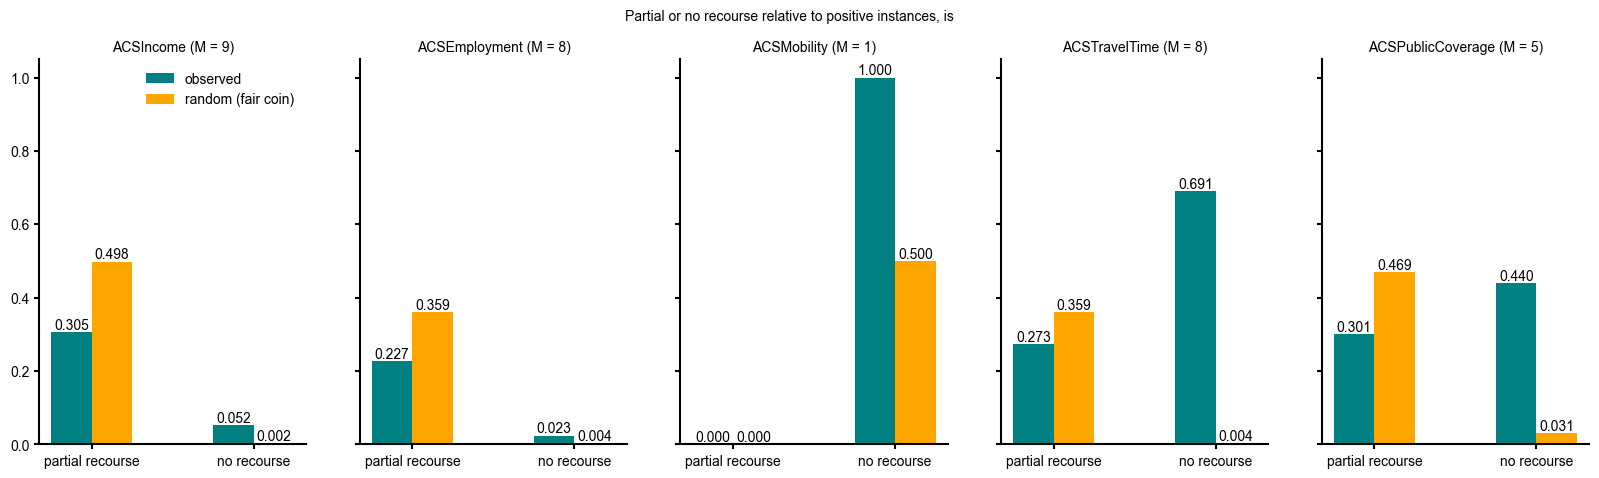

In [10]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(20,5), sharey=True); fig.suptitle('Partial or no recourse relative to positive instances, is')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {num_models})")

    num_models_rejected = num_models - predictions_above_baseline[task].sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_pos = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_pos = np.array([len(num_models_rejected_pos[num_models_rejected_pos==i]) for i in range(0,num_models+1)])

    partial_recourse = counts_rejects_pos[num_models//2+1:-1].sum()/indices_pos.shape[0]
    no_recourse = counts_rejects_pos[-1]/indices_pos.shape[0]

    width=0.25
    axs[i].set_xticks(np.arange(2)+0.5*width, [f'partial recourse', f'no recourse'])
    obs_bar = axs[i].bar(np.arange(2), [partial_recourse, no_recourse], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(2)+width, [prob_random[num_models//2+1:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge')
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge')

    if i==0:
        axs[i].legend()

# plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_to_positives.png')
plt.show()

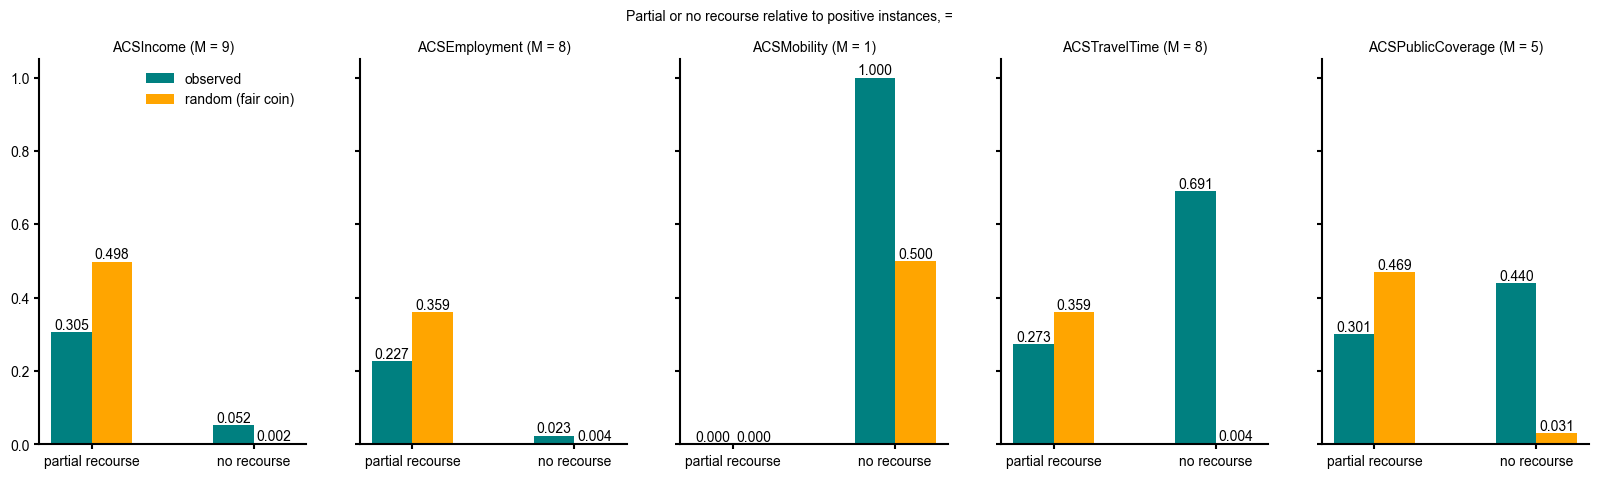

In [11]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(20,5), sharey=True); fig.suptitle('Partial or no recourse relative to positive instances, =')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {num_models})")

    num_models_rejected = num_models - predictions_above_baseline[task].sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_pos = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_pos = np.array([len(num_models_rejected_pos[num_models_rejected_pos==i]) for i in range(0,num_models+1)])

    partial_recourse = counts_rejects_pos[num_models//2+1:-1].sum()/indices_pos.shape[0]
    no_recourse = counts_rejects_pos[-1]/indices_pos.shape[0]

    width=0.25
    axs[i].set_xticks(np.arange(2)+0.5*width, [f'partial recourse', f'no recourse'])
    obs_bar = axs[i].bar(np.arange(2), [partial_recourse, no_recourse], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(2)+width, [prob_random[num_models//2+1:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge')
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge')

    if i==0:
        axs[i].legend()

# plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_to_positives.png')
plt.show()

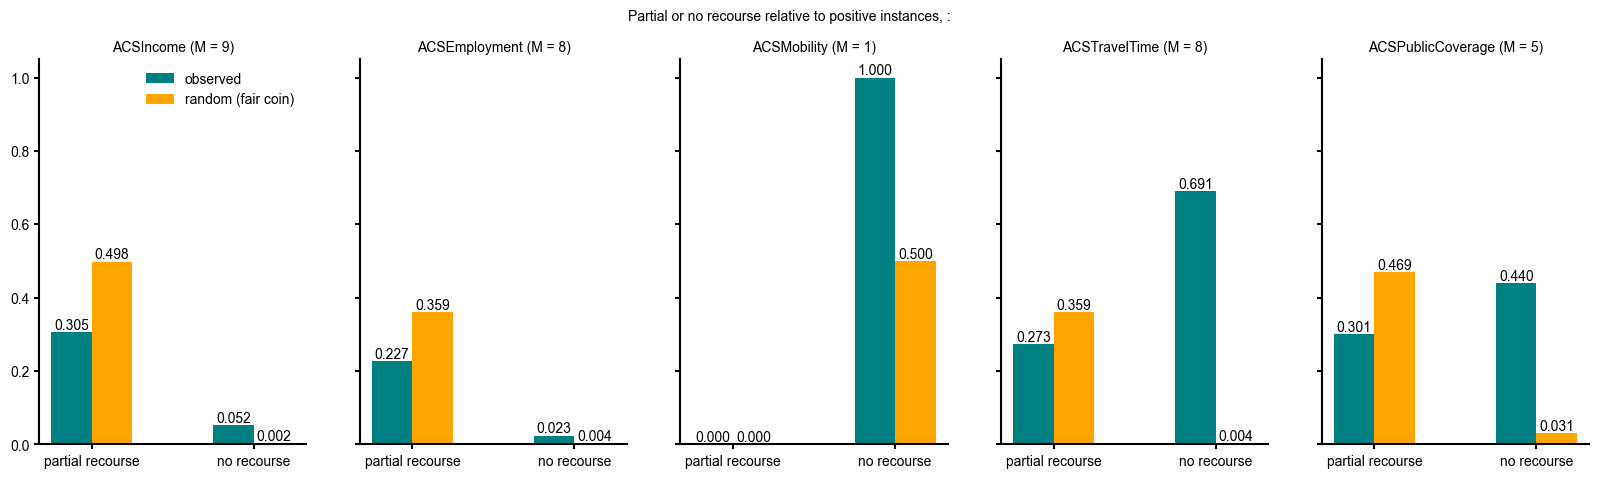

In [12]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(20,5), sharey=True); fig.suptitle('Partial or no recourse relative to positive instances, :')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {num_models})")

    num_models_rejected = num_models - predictions_above_baseline[task].sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_pos = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_pos = np.array([len(num_models_rejected_pos[num_models_rejected_pos==i]) for i in range(0,num_models+1)])

    partial_recourse = counts_rejects_pos[num_models//2+1:-1].sum()/indices_pos.shape[0]
    no_recourse = counts_rejects_pos[-1]/indices_pos.shape[0]

    width=0.25
    axs[i].set_xticks(np.arange(2)+0.5*width, [f'partial recourse', f'no recourse'])
    obs_bar = axs[i].bar(np.arange(2), [partial_recourse, no_recourse], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(2)+width, [prob_random[num_models//2+1:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge')
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge')

    if i==0:
        axs[i].legend()

# plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_to_positives.png')
plt.show()